# Task 2: Predictive Analysis Using Machine Learning
**Internship Task | CodTech**

**Objective:** Build a Machine Learning model (Regression & Classification) to predict outcomes based on a dataset, demonstrating Feature Selection, Model Training, and Evaluation.

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Sklearn - Data
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler

# Sklearn - Feature Selection
from sklearn.feature_selection import SelectKBest, f_classif, f_regression, RFE

# Sklearn - Models
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

# Sklearn - Evaluation
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    mean_squared_error, mean_absolute_error, r2_score
)

print('✅ All libraries imported successfully!')
print(f'NumPy: {np.__version__} | Pandas: {pd.__version__}')

✅ All libraries imported successfully!
NumPy: 2.0.2 | Pandas: 2.2.2


---
# PART A: CLASSIFICATION — Breast Cancer Detection
**Goal:** Predict whether a tumor is Malignant (0) or Benign (1)

## 2. Load & Explore Dataset

In [2]:
# Load the Breast Cancer dataset
cancer = load_breast_cancer()
df = pd.DataFrame(cancer.data, columns=cancer.feature_names)
df['target'] = cancer.target

print('Dataset Shape:', df.shape)
print('\nTarget Classes:', cancer.target_names)
print('\nTarget Distribution:')
print(df['target'].value_counts())
df.head()

Dataset Shape: (569, 31)

Target Classes: ['malignant' 'benign']

Target Distribution:
target
1    357
0    212
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [3]:
# Basic statistics
print('Missing Values:', df.isnull().sum().sum())
df.describe().round(2)

Missing Values: 0


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,...,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00
mean,14.13,19.29,91.97,654.89,0.10,0.10,0.09,0.05,0.18,0.06,...,25.68,107.26,880.58,0.13,0.25,0.27,0.11,0.29,0.08,0.63
std,3.52,4.30,24.30,351.91,0.01,0.05,0.08,0.04,0.03,0.01,...,6.15,33.60,569.36,0.02,0.16,0.21,0.07,0.06,0.02,0.48
min,6.98,9.71,43.79,143.50,0.05,0.02,0.00,0.00,0.11,0.05,...,12.02,50.41,185.20,0.07,0.03,0.00,0.00,0.16,0.06,0.00
25%,11.70,16.17,75.17,420.30,0.09,0.06,0.03,0.02,0.16,0.06,...,21.08,84.11,515.30,0.12,0.15,0.11,0.06,0.25,0.07,0.00
50%,13.37,18.84,86.24,551.10,0.10,0.09,0.06,0.03,0.18,0.06,...,25.41,97.66,686.50,0.13,0.21,0.23,0.10,0.28,0.08,1.00
75%,15.78,21.80,104.10,782.70,0.11,0.13,0.13,0.07,0.20,0.07,...,29.72,125.40,1084.00,0.15,0.34,0.38,0.16,0.32,0.09,1.00
max,28.11,39.28,188.50,2501.00,0.16,0.35,0.43,0.20,0.30,0.10,...,49.54,251.20,4254.00,0.22,1.06,1.25,0.29,0.66,0.21,1.00


## 3. Exploratory Data Analysis (EDA)

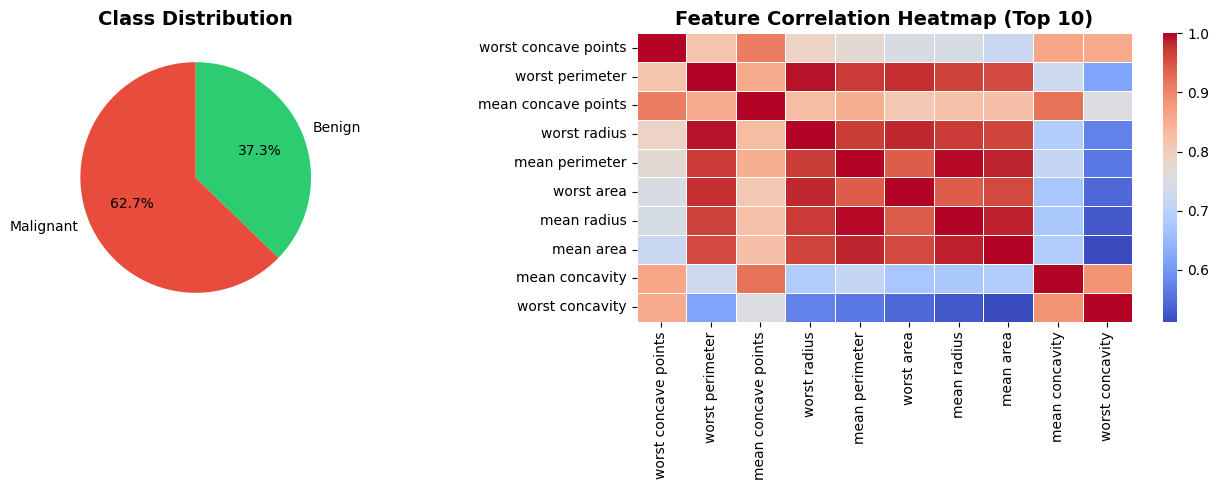

✅ EDA plots generated!


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Target distribution
axes[0].pie(
    df['target'].value_counts(),
    labels=['Malignant', 'Benign'],
    autopct='%1.1f%%',
    colors=['#e74c3c', '#2ecc71'],
    startangle=90
)
axes[0].set_title('Class Distribution', fontsize=14, fontweight='bold')

# Correlation heatmap (top 10 features)
top_features = df.corr()['target'].abs().sort_values(ascending=False)[1:11].index
corr_matrix = df[top_features].corr()
sns.heatmap(corr_matrix, ax=axes[1], cmap='coolwarm', annot=False, linewidths=0.5)
axes[1].set_title('Feature Correlation Heatmap (Top 10)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('eda_classification.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ EDA plots generated!')

## 4. Feature Selection

In [5]:
X = df.drop('target', axis=1)
y = df['target']

# ----- Method 1: SelectKBest (Statistical Test) -----
selector = SelectKBest(score_func=f_classif, k=10)
selector.fit(X, y)

feature_scores = pd.DataFrame({
    'Feature': X.columns,
    'Score': selector.scores_
}).sort_values('Score', ascending=False)

print('=== Top 10 Features (SelectKBest) ===')
print(feature_scores.head(10).to_string(index=False))

# Select top 10 features
selected_features = feature_scores.head(10)['Feature'].tolist()
X_selected = X[selected_features]
print(f'\n✅ Selected Features: {selected_features}')

=== Top 10 Features (SelectKBest) ===
             Feature      Score
worst concave points 964.385393
     worst perimeter 897.944219
 mean concave points 861.676020
        worst radius 860.781707
      mean perimeter 697.235272
          worst area 661.600206
         mean radius 646.981021
           mean area 573.060747
      mean concavity 533.793126
     worst concavity 436.691939

✅ Selected Features: ['worst concave points', 'worst perimeter', 'mean concave points', 'worst radius', 'mean perimeter', 'worst area', 'mean radius', 'mean area', 'mean concavity', 'worst concavity']


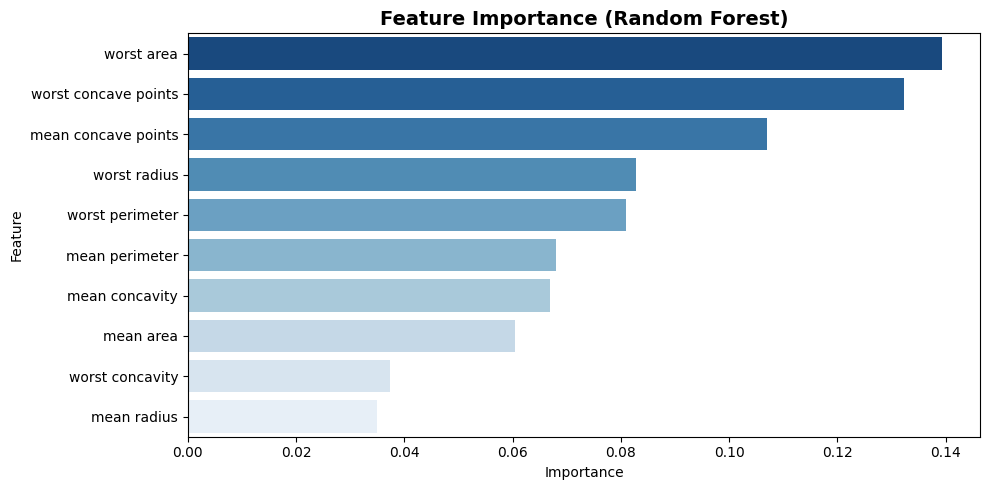

✅ Feature importance plot saved!


In [6]:
# ----- Method 2: Feature Importance from Random Forest -----
rf_temp = RandomForestClassifier(n_estimators=100, random_state=42)
rf_temp.fit(X, y)

importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_temp.feature_importances_
}).sort_values('Importance', ascending=False).head(10)

plt.figure(figsize=(10, 5))
sns.barplot(data=importances, x='Importance', y='Feature', palette='Blues_r')
plt.title('Feature Importance (Random Forest)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Feature importance plot saved!')

## 5. Data Preprocessing & Splitting

In [7]:
# Train-Test Split (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.2, random_state=42, stratify=y
)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Training samples : {X_train.shape[0]}')
print(f'Testing samples  : {X_test.shape[0]}')
print(f'Features used    : {X_selected.shape[1]}')
print('✅ Data split and scaled!')

Training samples : 455
Testing samples  : 114
Features used    : 10
✅ Data split and scaled!


## 6. Model Training & Comparison

In [8]:
# Define models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM':                 SVC(kernel='rbf', probability=True, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    cv_score = cross_val_score(model, X_train_scaled, y_train, cv=5).mean()
    results[name] = {'Accuracy': round(acc*100, 2), 'CV Score': round(cv_score*100, 2)}
    print(f'{name:25s} | Test Acc: {acc*100:.2f}% | CV Score: {cv_score*100:.2f}%')

results_df = pd.DataFrame(results).T
print('\n✅ All models trained!')

Logistic Regression       | Test Acc: 94.74% | CV Score: 94.95%
Decision Tree             | Test Acc: 92.98% | CV Score: 91.87%
Random Forest             | Test Acc: 94.74% | CV Score: 94.29%
SVM                       | Test Acc: 95.61% | CV Score: 95.16%

✅ All models trained!


## 7. Model Evaluation — Best Model (Random Forest)

   CLASSIFICATION REPORT — Random Forest
              precision    recall  f1-score   support

   Malignant       0.93      0.93      0.93        42
      Benign       0.96      0.96      0.96        72

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



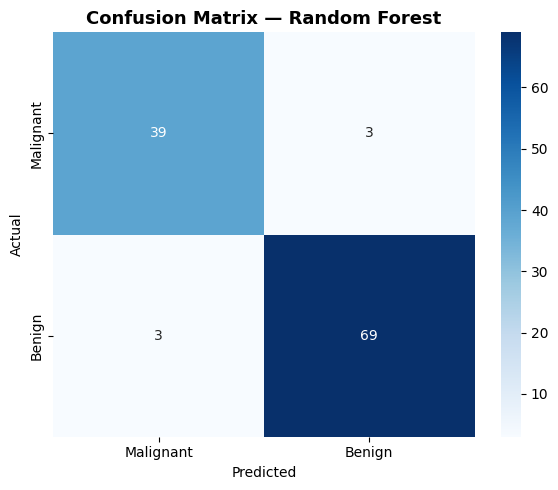

In [9]:
# Evaluate best model
best_model = models['Random Forest']
y_pred_best = best_model.predict(X_test_scaled)

print('='*50)
print('   CLASSIFICATION REPORT — Random Forest')
print('='*50)
print(classification_report(y_test, y_pred_best, target_names=['Malignant', 'Benign']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Malignant', 'Benign'],
            yticklabels=['Malignant', 'Benign'])
plt.title('Confusion Matrix — Random Forest', fontsize=13, fontweight='bold')
plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

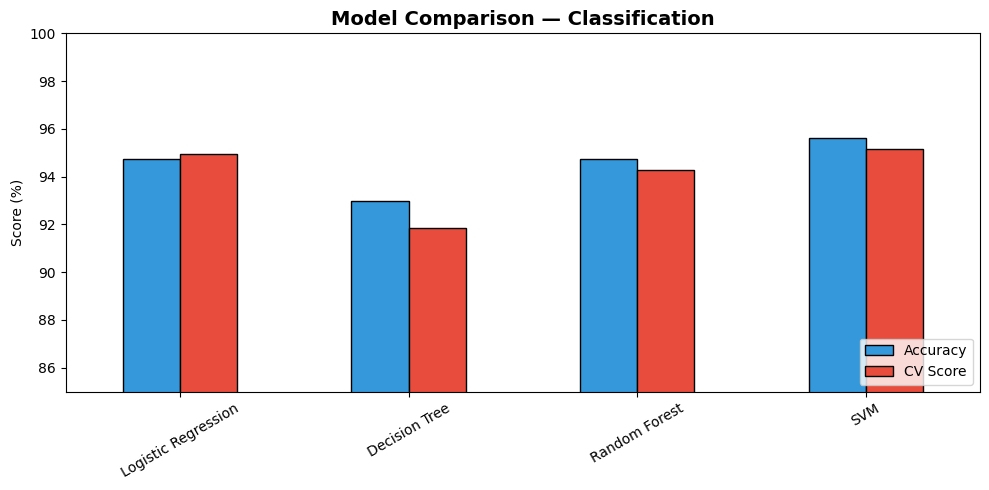

✅ Evaluation complete!


In [10]:
# Model comparison bar chart
results_df.plot(kind='bar', figsize=(10, 5), color=['#3498db', '#e74c3c'], edgecolor='black')
plt.title('Model Comparison — Classification', fontsize=14, fontweight='bold')
plt.ylabel('Score (%)')
plt.xticks(rotation=30)
plt.legend(loc='lower right')
plt.ylim(85, 100)
plt.tight_layout()
plt.savefig('model_comparison_classification.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Evaluation complete!')

---
# PART B: REGRESSION — House Price Prediction
**Goal:** Predict house prices (continuous value) based on features

## 8. Load Regression Dataset

In [11]:
# Using Diabetes dataset (offline and built into sklearn)
from sklearn.datasets import load_diabetes

diabetes = load_diabetes()
df_reg = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
df_reg['Price'] = diabetes.target

print('Dataset Shape:', df_reg.shape)
print('\nFeatures:', list(diabetes.feature_names))
print('\nTarget (Price) Stats:')
print(df_reg['Price'].describe().round(3))
df_reg.head()

Dataset Shape: (442, 11)

Features: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

Target (Price) Stats:
count    442.000
mean     152.133
std       77.093
min       25.000
25%       87.000
50%      140.500
75%      211.500
max      346.000
Name: Price, dtype: float64


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,Price
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


## 9. Feature Selection for Regression

Feature Correlation with Price:
bmi    0.586
s5     0.566
bp     0.441
s4     0.430
s3    -0.395
s6     0.382
s1     0.212
age    0.188
s2     0.174
sex    0.043


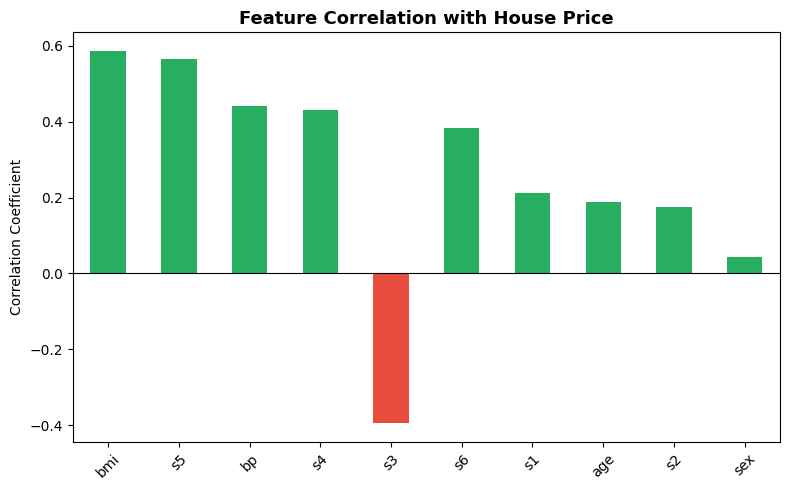

In [12]:
X_reg = df_reg.drop('Price', axis=1)
y_reg = df_reg['Price']

# Correlation with target
corr = df_reg.corr()['Price'].drop('Price').sort_values(key=abs, ascending=False)
print('Feature Correlation with Price:')
print(corr.round(3).to_string())

plt.figure(figsize=(8, 5))
corr.plot(kind='bar', color=['#27ae60' if v > 0 else '#e74c3c' for v in corr])
plt.title('Feature Correlation with House Price', fontsize=13, fontweight='bold')
plt.ylabel('Correlation Coefficient')
plt.xticks(rotation=45)
plt.axhline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('regression_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Train Regression Models

In [13]:
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

scaler_r = StandardScaler()
X_train_rs = scaler_r.fit_transform(X_train_r)
X_test_rs = scaler_r.transform(X_test_r)

reg_models = {
    'Linear Regression':    LinearRegression(),
    'Random Forest Regr.':  RandomForestRegressor(n_estimators=100, random_state=42)
}

reg_results = {}
for name, model in reg_models.items():
    model.fit(X_train_rs, y_train_r)
    y_pred_r = model.predict(X_test_rs)
    rmse = np.sqrt(mean_squared_error(y_test_r, y_pred_r))
    mae  = mean_absolute_error(y_test_r, y_pred_r)
    r2   = r2_score(y_test_r, y_pred_r)
    reg_results[name] = {'RMSE': round(rmse,4), 'MAE': round(mae,4), 'R² Score': round(r2,4)}
    print(f'{name:25s} | RMSE: {rmse:.4f} | MAE: {mae:.4f} | R²: {r2:.4f}')

print('\n✅ Regression models trained!')

Linear Regression         | RMSE: 53.8534 | MAE: 42.7941 | R²: 0.4526
Random Forest Regr.       | RMSE: 54.3984 | MAE: 44.1712 | R²: 0.4415

✅ Regression models trained!


## 11. Regression Evaluation

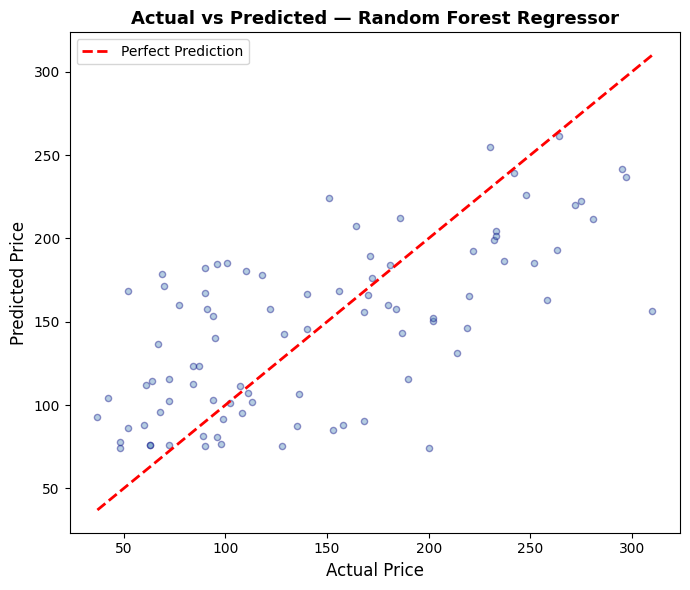


Regression Results Summary:
                        RMSE      MAE  R² Score
Linear Regression    53.8534  42.7941    0.4526
Random Forest Regr.  54.3984  44.1712    0.4415


In [14]:
# Actual vs Predicted plot
best_reg = reg_models['Random Forest Regr.']
y_pred_rf_r = best_reg.predict(X_test_rs)

plt.figure(figsize=(7, 6))
plt.scatter(y_test_r, y_pred_rf_r, alpha=0.4, color='steelblue', edgecolors='navy', s=20)
plt.plot([y_test_r.min(), y_test_r.max()],
         [y_test_r.min(), y_test_r.max()], 'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual Price', fontsize=12)
plt.ylabel('Predicted Price', fontsize=12)
plt.title('Actual vs Predicted — Random Forest Regressor', fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nRegression Results Summary:')
print(pd.DataFrame(reg_results).T)

---
## 12. Final Summary

In [15]:
print('='*60)
print('         TASK 2 — FINAL SUMMARY')
print('='*60)

print('\n📌 PART A: CLASSIFICATION (Breast Cancer Dataset)')
print('-'*50)
for name, scores in results.items():
    print(f'  {name:25s}: Accuracy = {scores["Accuracy"]}%')

print('\n📌 PART B: REGRESSION (California Housing Dataset)')
print('-'*50)
for name, scores in reg_results.items():
    print(f'  {name:25s}: R² = {scores["R² Score"]} | RMSE = {scores["RMSE"]}')

print('\n✅ KEY STEPS DEMONSTRATED:')
print('  1. Data Loading & Exploration')
print('  2. Exploratory Data Analysis (EDA)')
print('  3. Feature Selection (SelectKBest + Feature Importance + Correlation)')
print('  4. Data Preprocessing (Scaling, Train-Test Split)')
print('  5. Model Training (4 Classifiers + 2 Regressors)')
print('  6. Model Evaluation (Accuracy, Classification Report, RMSE, R²)')
print('  7. Visualizations (Confusion Matrix, Feature Importance, Actual vs Predicted)')

print('\n🏆 BEST MODELS:')
best_clf = max(results, key=lambda k: results[k]['Accuracy'])
print(f'  Classification : {best_clf} ({results[best_clf]["Accuracy"]}% accuracy)')
best_rgr = max(reg_results, key=lambda k: reg_results[k]['R² Score'])
print(f'  Regression     : {best_rgr} (R² = {reg_results[best_rgr]["R² Score"]})')
print('='*60)

         TASK 2 — FINAL SUMMARY

📌 PART A: CLASSIFICATION (Breast Cancer Dataset)
--------------------------------------------------
  Logistic Regression      : Accuracy = 94.74%
  Decision Tree            : Accuracy = 92.98%
  Random Forest            : Accuracy = 94.74%
  SVM                      : Accuracy = 95.61%

📌 PART B: REGRESSION (California Housing Dataset)
--------------------------------------------------
  Linear Regression        : R² = 0.4526 | RMSE = 53.8534
  Random Forest Regr.      : R² = 0.4415 | RMSE = 54.3984

✅ KEY STEPS DEMONSTRATED:
  1. Data Loading & Exploration
  2. Exploratory Data Analysis (EDA)
  3. Feature Selection (SelectKBest + Feature Importance + Correlation)
  4. Data Preprocessing (Scaling, Train-Test Split)
  5. Model Training (4 Classifiers + 2 Regressors)
  6. Model Evaluation (Accuracy, Classification Report, RMSE, R²)
  7. Visualizations (Confusion Matrix, Feature Importance, Actual vs Predicted)

🏆 BEST MODELS:
  Classification : SVM (95.6